In [28]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


AssertionError: Did you change the path? It should be one of ['/home/export/soheuny/SRFinder/soheun/notebooks', '/home/soheuny/HH4bsim/soheun/notebooks']

In [49]:
import ROOT
import pathlib

directory = pathlib.Path("../events/MG3")
f = ROOT.TFile(str(directory / "TTree" / "HH4b_400.root"))
f.ls()
t = f.Get("Tree")
t.Print()

print(t.GetEntries())
t.GetEntry(5000)
print(t.jetPt[1])

44196
98.81907653808594
TFile**		../events/MG3/TTree/HH4b_400.root	
 TFile*		../events/MG3/TTree/HH4b_400.root	
  KEY: TTree	Tree;1	hists/S400HH4b
******************************************************************************
*Tree    :Tree      : hists/S400HH4b                                         *
*Entries :    44196 : Total =         5505919 bytes  File  Size =    3943611 *
*        :          : Tree compression factor =   1.39                       *
******************************************************************************
*Br    0 :nJets     : nJets/I                                                *
*Entries :    44196 : Total  Size=     177701 bytes  File Size  =       1507 *
*Baskets :        6 : Basket Size=      32000 bytes  Compression= 117.60     *
*............................................................................*
*Br    1 :jetPt     : jetPt[nJets]/F                                         *
*Entries :    44196 : Total  Size=     887716 bytes  File Size 

In [2]:
from copy import deepcopy
import logging
import torch
import pandas as pd
import numpy as np
import pytorch_lightning as pl
import click
import yaml


from fvt_classifier import FvTClassifier
from dataset import MotherSamples
from training_info import TrainingInfo
from utils import require_keys

n_3b = 100_0000
ratio_4b = 0.5
signal_ratio = 0.005
signal_filename = "HH4b_resonant_picoAOD_v1.h5"
# seed = 0

ms_hparams = {
        "n_3b": n_3b,
        "ratio_4b": ratio_4b,
        "signal_ratio": signal_ratio,
        "signal_filename": signal_filename,
        # "seed": seed,
    }
hashes = MotherSamples.find(ms_hparams, from_metadata=False)

754it [00:03, 193.19it/s]


In [3]:
len(hashes)

254

In [3]:
# import ROOT
# import pathlib


# directory = pathlib.Path("../../events/MG3")
# f = ROOT.TFile(str(directory / "TTree" / "fourTag_10x_picoAOD.root"))
# # f.ls()
# t = f.Get("Events")
# t.Print()

# data = {
#     "Jet0_pt": [],
#     "Jet1_pt": [],
#     "Jet2_pt": [],
#     "Jet3_pt": [],
#     "Jet0_eta": [],
#     "Jet1_eta": [],
#     "Jet2_eta": [],
#     "Jet3_eta": [],
#     "Jet0_phi": [],
#     "Jet1_phi": [],
#     "Jet2_phi": [],
#     "Jet3_phi": [],
#     "Jet0_m": [],
#     "Jet1_m": [],
#     "Jet2_m": [],
#     "Jet3_m": [],
#     "m01": [],
#     "m23": [],
#     "m02": [],
#     "m13": [],
#     "m03": [],
#     "m12": [],
# }



Welcome to JupyROOT 6.30/04


Error in <TFile::TFile>: file /home/export/soheuny/SRFinder/soheun/../../events/MG3/TTree/fourTag_10x_picoAOD.root does not exist


OSError: Failed to open file ../../events/MG3/TTree/fourTag_10x_picoAOD.root

In [2]:
import pandas as pd
import numpy as np

data = {
    "Jet0_pt": [],
    "Jet1_pt": [],
    "Jet2_pt": [],
    "Jet3_pt": [],
    "Jet0_eta": [],
    "Jet1_eta": [],
    "Jet2_eta": [],
    "Jet3_eta": [],
    "Jet0_phi": [],
    "Jet1_phi": [],
    "Jet2_phi": [],
    "Jet3_phi": [],
    "Jet0_m": [],
    "Jet1_m": [],
    "Jet2_m": [],
    "Jet3_m": [],
    "m01": [],
    "m23": [],
    "m02": [],
    "m13": [],
    "m03": [],
    "m12": [],
}
for idx in range(10000):
    t.GetEntry(idx)
    data["Jet0_pt"].append(t.Jet_pt[0])
    data["Jet1_pt"].append(t.Jet_pt[1])
    data["Jet2_pt"].append(t.Jet_pt[2])
    data["Jet3_pt"].append(t.Jet_pt[3])
    data["Jet0_eta"].append(t.Jet_eta[0])
    data["Jet1_eta"].append(t.Jet_eta[1])
    data["Jet2_eta"].append(t.Jet_eta[2])
    data["Jet3_eta"].append(t.Jet_eta[3])
    data["Jet0_phi"].append(t.Jet_phi[0])
    data["Jet1_phi"].append(t.Jet_phi[1])
    data["Jet2_phi"].append(t.Jet_phi[2])
    data["Jet3_phi"].append(t.Jet_phi[3])
    data["Jet0_m"].append(t.Jet_mass[0])
    data["Jet1_m"].append(t.Jet_mass[1])
    data["Jet2_m"].append(t.Jet_mass[2])
    data["Jet3_m"].append(t.Jet_mass[3])

    jets = [
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
            ]
    for i in range(4):
        jets[i].SetPtEtaPhiM(
            t.Jet_pt[i], t.Jet_eta[i], t.Jet_phi[i], t.Jet_mass[i]
        )

    data["m01"].append((jets[0] + jets[1]).M())
    data["m23"].append((jets[2] + jets[3]).M())
    data["m02"].append((jets[0] + jets[2]).M())
    data["m13"].append((jets[1] + jets[3]).M())
    data["m03"].append((jets[0] + jets[3]).M())
    data["m12"].append((jets[1] + jets[2]).M())
    
df = pd.DataFrame(data)

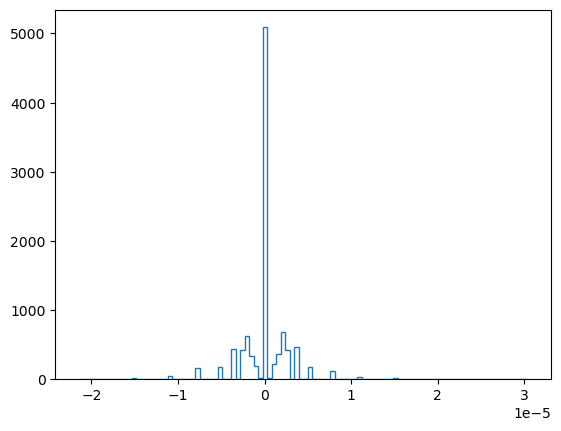

In [4]:
import matplotlib.pyplot as plt
plt.hist(df["Jet0_m"], bins=100, histtype="step")
plt.show()

In [5]:
import torch
import pathlib
import numpy as np
import pandas as pd

seed_ = 42

dim = 16
directory = pathlib.Path("../events/MG3")

df_3b = pd.read_hdf(directory / "dataframes" / "bbbj.h5")
df_bg4b = pd.read_hdf(directory / "dataframes" / "bbbb_large.h5")
df_hh4b = pd.read_hdf(directory / "dataframes" / "HH4b.h5")

df_3b["signal"] = False
df_bg4b["signal"] = False
df_hh4b["signal"] = True

print("3b-jet events: ", len(df_3b))
print("4b-jet events: ", len(df_bg4b))
print("HH4b-jet events: ", len(df_hh4b))

# shuffle the data
df_3b = df_3b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_bg4b = df_bg4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b = df_hh4b.sample(frac=1, random_state=seed_).reset_index(drop=True)

3b-jet events:  275508
4b-jet events:  382108
HH4b-jet events:  28656


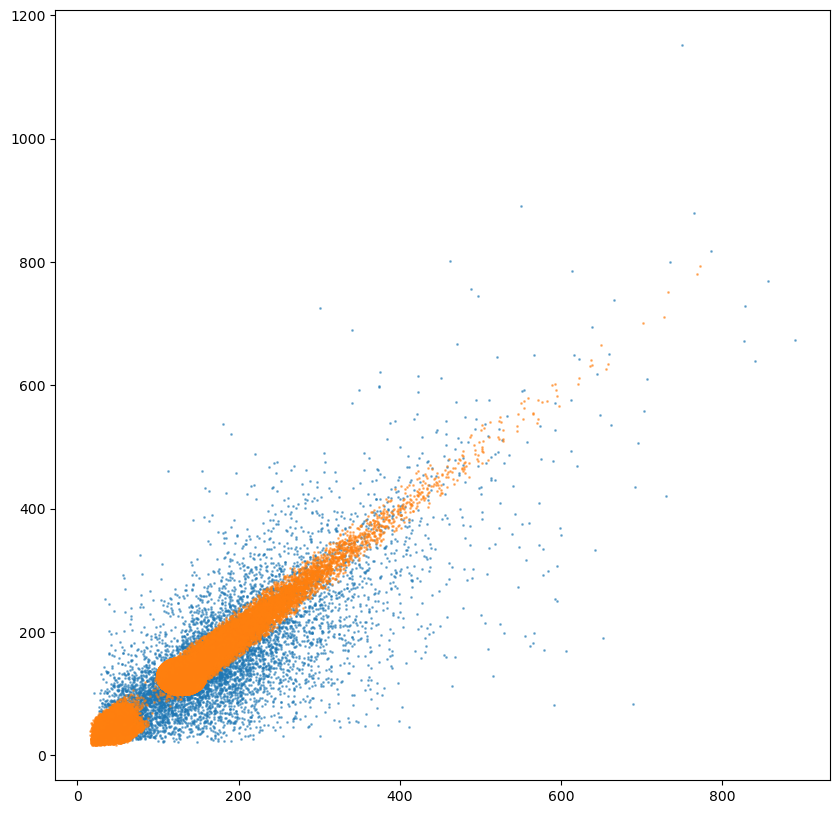

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

m_diff = np.stack(
    [df["m01"] - df["m23"],
     df["m02"] - df["m13"], 
     df["m03"] - df["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df["m01"],
                np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
m2 = np.where(m_diff_argmin == 0, df["m23"],
                np.where(m_diff_argmin == 1, df["m13"], df["m12"]))

ax.plot(m1, m2, "o", alpha=0.5, markersize=1)


m_diff = np.stack(
    [df_bg4b["m01"] - df_bg4b["m23"],
     df_bg4b["m02"] - df_bg4b["m13"], 
     df_bg4b["m03"] - df_bg4b["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df_bg4b["m01"],
                np.where(m_diff_argmin == 1, df_bg4b["m02"], df_bg4b["m03"]))
m2 = np.where(m_diff_argmin == 0, df_bg4b["m23"],
                np.where(m_diff_argmin == 1, df_bg4b["m13"], df_bg4b["m12"]))
ax.plot(m1, m2, "o", alpha=0.5, markersize=1)

plt.show()
plt.close()


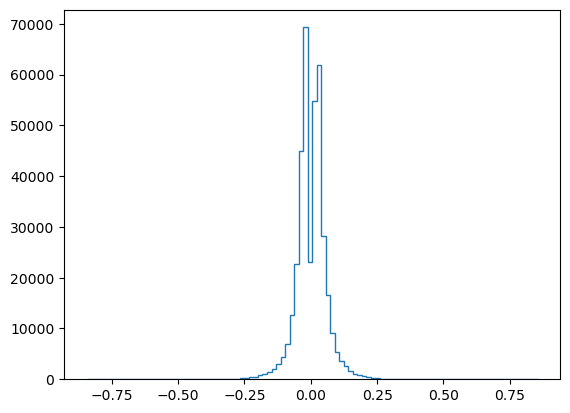

In [7]:
plt.hist(df_bg4b["canJet0_m"], bins=100, histtype="step")
plt.show()
plt.close()

In [50]:
import matplotlib.pyplot as plt
import pathlib
import pandas as pd

seed_ = 42

dim = 16
directory = pathlib.Path("../events/MG3")

df_3b = pd.read_hdf(directory / "dataframes" / "threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf(directory / "dataframes" / "fourTag_10x_picoAOD.h5")
df_hh4b = pd.read_hdf(directory / "dataframes" / "HH4b_picoAOD.h5")
df_hh4b_400 = pd.read_hdf(directory / "dataframes" / "HH4b_400.h5")
df_hh4b_800 = pd.read_hdf(directory / "dataframes" / "HH4b_800.h5")

df_3b["signal"] = False
df_bg4b["signal"] = False
df_hh4b["signal"] = True
df_hh4b_400["signal"] = True
df_hh4b_800["signal"] = True

print("3b-jet events: ", len(df_3b))
print("4b-jet events: ", len(df_bg4b))
print("HH4b-jet events: ", len(df_hh4b))
print("HH4b_400-jet events: ", len(df_hh4b_400))
print("HH4b_800-jet events: ", len(df_hh4b_800))

# shuffle the data
df_3b = df_3b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_bg4b = df_bg4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b = df_hh4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b_400 = df_hh4b_400.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b_800 = df_hh4b_800.sample(frac=1, random_state=seed_).reset_index(drop=True)


3b-jet events:  2013103
4b-jet events:  2202261
HH4b-jet events:  30856
HH4b_400-jet events:  44196
HH4b_800-jet events:  97038


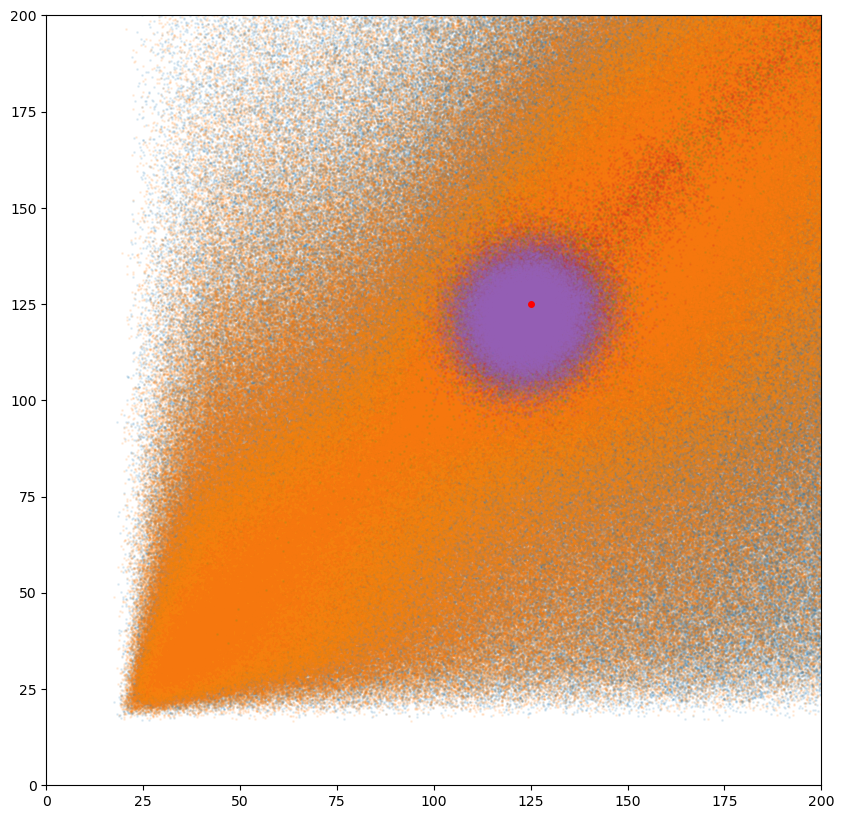

In [51]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
for df in [df_3b, df_bg4b, df_hh4b, df_hh4b_400, df_hh4b_800]:
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    ax.plot(m1, m2, "o", alpha=0.1, markersize=1)

ax.plot(125, 125, "o", markersize=4, color="red")
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)

plt.show()
plt.close()


In [52]:
df_hh4b_800

,Jet0_pt,Jet1_pt,Jet2_pt,Jet3_pt,Jet0_eta,Jet1_eta,Jet2_eta,Jet3_eta,Jet0_phi,Jet1_phi,...,dR02,dR13,dR03,dR12,dR0123,dR0213,dR0312,s4j,m4j,signal
0,305.967346,251.179016,129.168259,85.553810,-0.127297,-0.379113,-0.400356,0.212295,-1.437016,1.351651,...,2.764055,2.894760,0.742966,0.744287,3.022190,3.084861,3.127605,771.868408,786.233704,True
1,319.381348,176.206589,155.287842,43.395935,-0.000793,0.325073,0.966980,-0.662660,-1.115835,1.777246,...,3.225449,2.795776,1.018877,0.667691,3.081813,3.075447,3.154988,694.271729,765.095703,True
2,308.214752,223.652405,147.247681,61.974106,-1.043238,-1.745935,-1.922334,-1.809646,-0.194526,2.279022,...,3.259436,2.800550,0.832969,0.693789,2.583319,2.354045,2.866733,741.088928,786.840820,True
3,239.788925,227.385483,157.429184,96.038292,-0.485812,0.381411,-0.442370,-0.108058,-0.425438,2.265785,...,0.632312,0.829856,2.946146,3.073596,2.539064,3.220288,3.242040,720.641907,770.840515,True
4,133.040100,127.112679,97.184143,76.068687,-1.882959,0.698636,0.671742,-1.043962,1.936928,-1.643388,...,3.565639,2.501960,1.235949,1.093222,2.541150,3.656414,3.802061,433.405609,768.108154,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97033,357.631958,197.675354,159.257797,119.532814,-0.226103,-0.310282,-0.632233,-0.118346,2.373650,-0.296324,...,2.976319,2.056530,0.631679,0.738594,2.195701,2.219859,2.826782,834.097900,827.012817,True
97034,337.972443,301.049622,72.841690,61.469982,-1.176216,-0.763799,-1.586242,-1.686856,-0.886356,2.316975,...,2.861944,2.628910,0.801921,0.858858,1.859571,2.871418,2.957350,773.333740,807.353638,True
97035,386.919891,236.017075,146.586197,61.226334,0.009327,-0.457687,-0.533377,0.127844,2.723577,-0.655992,...,2.687791,2.628221,0.825950,0.750963,2.551039,2.940740,3.042767,830.749512,853.511230,True
97036,250.692184,210.800476,107.799515,65.244614,1.418399,0.230590,0.562906,1.578945,2.292647,-0.900688,...,2.681615,2.531178,0.961203,0.731664,3.228283,3.272245,3.332313,634.536804,739.709045,True


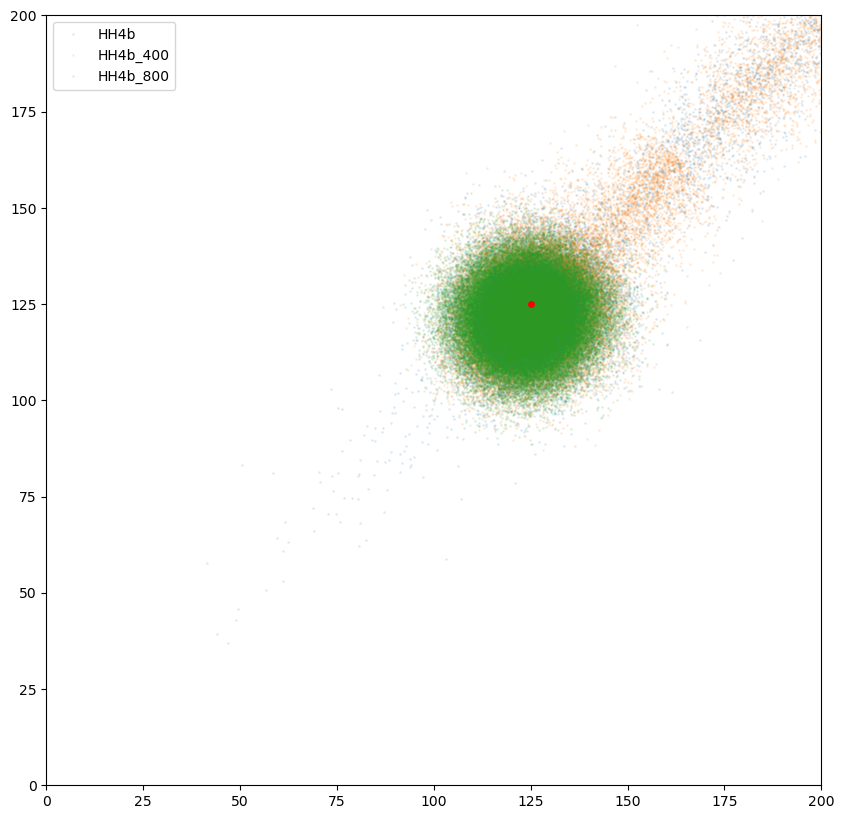

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
for label, df in [("HH4b", df_hh4b), ("HH4b_400", df_hh4b_400), ("HH4b_800", df_hh4b_800)]:
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    ax.plot(m1, m2, "o", alpha=0.1, markersize=1, label=label)

ax.plot(125, 125, "o", markersize=4, color="red")
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)

ax.legend()
plt.show()
plt.close()


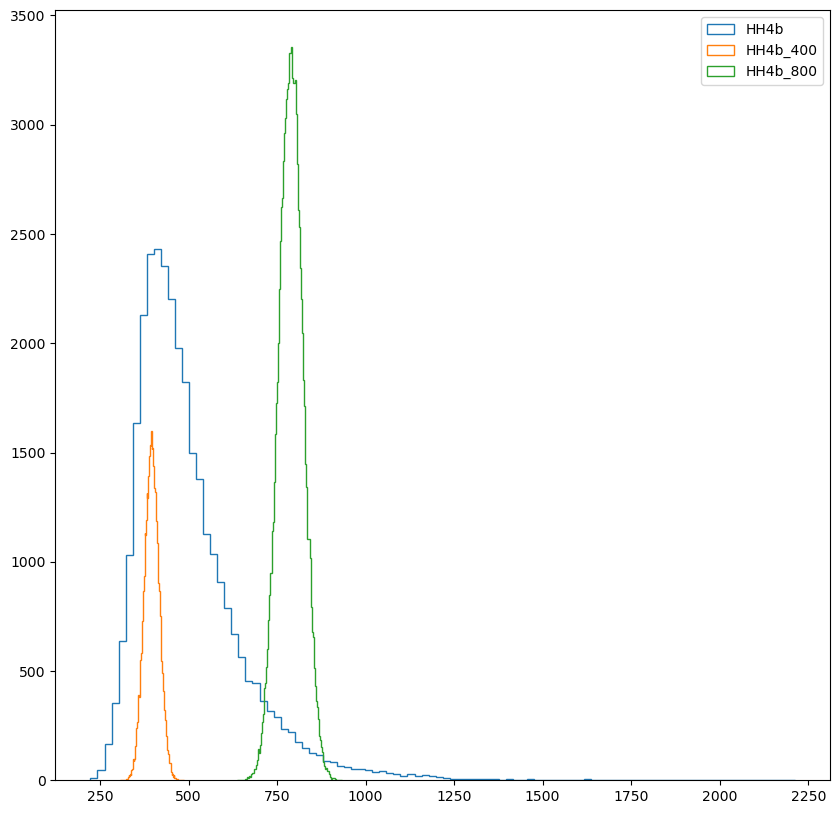

In [56]:
fig, ax = plt.subplots(figsize=(10, 10))
for label, df in [("HH4b", df_hh4b), ("HH4b_400", df_hh4b_400), ("HH4b_800", df_hh4b_800)]:
    ax.hist(df["m4j"], bins=100, histtype="step", label=label)
ax.legend()
plt.show()
plt.close()


3b in SR: 0.07266294869164668
Background $\mathrm{4b}$ in SR: 0.08501353835898652
$\mathrm{HH} \rightarrow 4b$ in SR: 0.8047705470572984


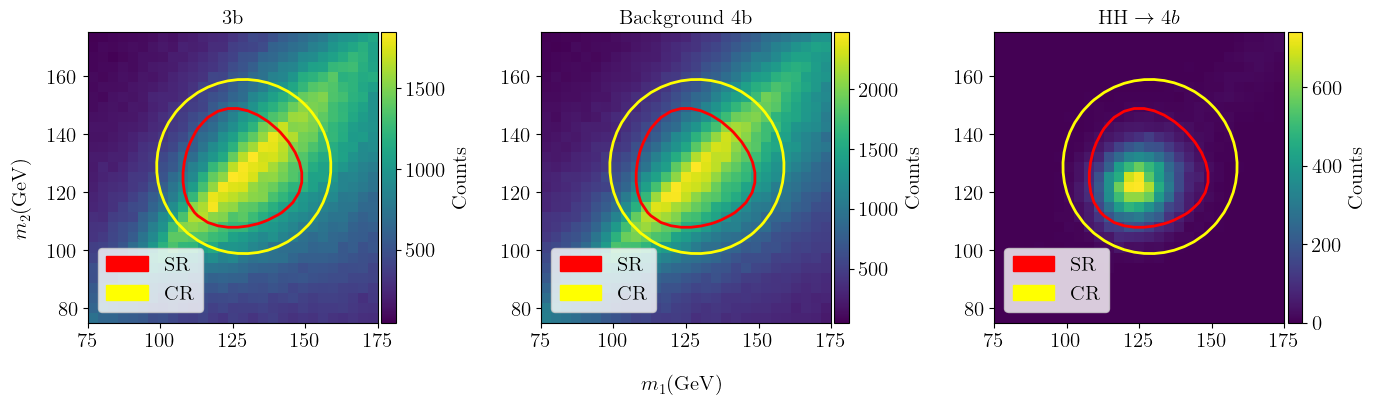

In [6]:
# density plot
from matplotlib import patches as mpatches

CR_color = "#0070c0"
SR_color = "#4ea230"


# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
fig.supxlabel("$m_1 (\mathrm{GeV})$")
fig.supylabel("$m_2 (\mathrm{GeV})$")
for ax, (name, df) in zip(axs, [("3b", df_3b), (r"Background $\mathrm{4b}$", df_bg4b), (r"$\mathrm{HH} \rightarrow 4b$", df_hh4b)]):
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    
    print(f"{name} in SR: {np.mean(SR_fn(m1, m2) < K_s)}")
    
    # heatmap
    m_min = 75
    m_max = 175
    xedges = np.linspace(m_min, m_max, 30)
    yedges = np.linspace(m_min, m_max, 30)
    H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
    H = H.T
    X, Y = np.meshgrid(xedges, yedges)
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")

    # add colorbar
    cbar = plt.colorbar(ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis"), fraction=0.047, pad=0.01)
    cbar.set_label("Counts")

    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    
    ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors=SR_color, linewidths=2)
    ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors=CR_color, linewidths=2)
    
    # add manual legend
    
    SR_patch = mpatches.Patch(color=SR_color, label="SR")
    CR_patch = mpatches.Patch(color=CR_color, label="CR")
    ax.legend(handles=[SR_patch, CR_patch], loc="lower left")
    ax.set_aspect("equal")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("./figures/m1m2_heatmap.png", dpi=300)
plt.show()
plt.close()


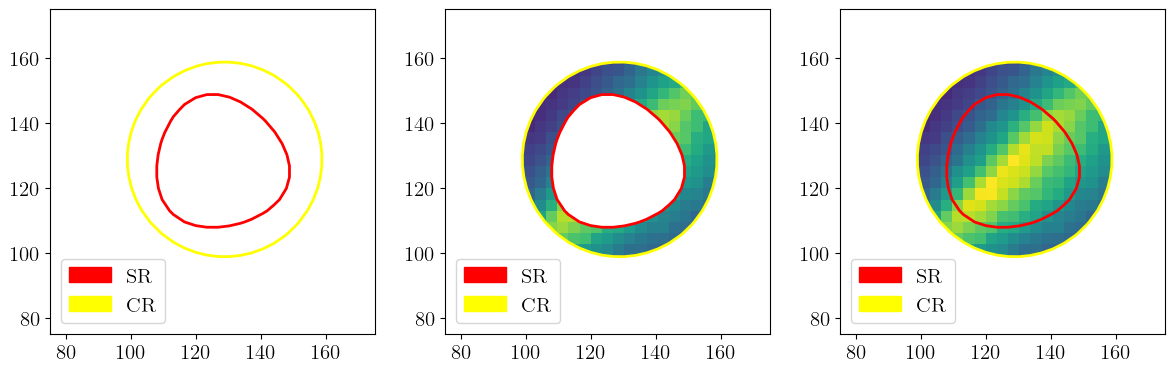

In [4]:
# density plot
import numpy as np
from matplotlib import patches as mpatches

SR_color = "#4ea230"
CR_color = "#0070c0"

# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15
plt.rcParams["figure.titlesize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

m_diff = np.stack(
    [df_bg4b["m01"] - df_bg4b["m23"],
    df_bg4b["m02"] - df_bg4b["m13"], 
    df_bg4b["m03"] - df_bg4b["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df_bg4b["m01"],
                np.where(m_diff_argmin == 1, df_bg4b["m02"], df_bg4b["m03"]))
m2 = np.where(m_diff_argmin == 0, df_bg4b["m23"],
                np.where(m_diff_argmin == 1, df_bg4b["m13"], df_bg4b["m12"]))

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
# fig.suptitle("Background $\mathrm{4b}$")
# fig.supxlabel("$m_1 (\mathrm{GeV})$")
# fig.supylabel("$m_2 (\mathrm{GeV})$")

# heatmap
m_min = 75
m_max = 175
xedges = np.linspace(m_min, m_max, 30)
yedges = np.linspace(m_min, m_max, 30)
H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
H = H.T
X, Y = np.meshgrid(xedges, yedges)


for ax in axs:
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")
    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    ax.set_aspect("equal")
    ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors=SR_color, linewidths=2)
    ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors=CR_color, linewidths=2)


axs[0].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[0].contourf(X, Y, CR_fn(X, Y), levels=[0, np.inf], colors="white")
axs[1].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[1].contourf(X, Y, CR_fn(X, Y), levels=[K_c, np.inf], colors="white")
# axs[2].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[2].contourf(X, Y, CR_fn(X, Y), levels=[K_c, np.inf], colors="white")

for ax in axs:
    SR_patch = mpatches.Patch(color=SR_color, label="SR")
    CR_patch = mpatches.Patch(color=CR_color, label="CR")
    ax.legend(handles=[SR_patch, CR_patch], loc="lower left")

plt.tight_layout()
plt.savefig("./figures/SR_bg4b_interpolation.png", dpi=300)
plt.show()
plt.close()


$\mathrm{HH} \rightarrow 4b$ in SR: 0.8047705470572984


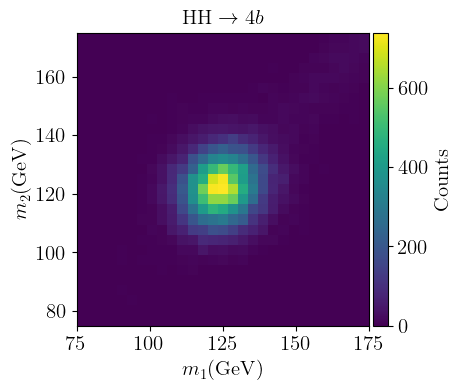

In [9]:
# density plot
from matplotlib import patches as mpatches

# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

fig, axs = plt.subplots(1, 1, figsize=(5, 4))
axs.set_xlabel("$m_1 (\mathrm{GeV})$")
axs.set_ylabel("$m_2 (\mathrm{GeV})$")
for ax, (name, df) in zip([axs], [(r"$\mathrm{HH} \rightarrow 4b$", df_hh4b)]):
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    
    print(f"{name} in SR: {np.mean(SR_fn(m1, m2) < K_s)}")
    
    # heatmap
    m_min = 75
    m_max = 175
    xedges = np.linspace(m_min, m_max, 30)
    yedges = np.linspace(m_min, m_max, 30)
    H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
    H = H.T
    X, Y = np.meshgrid(xedges, yedges)
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")

    # add colorbar
    cbar = plt.colorbar(ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis"), fraction=0.047, pad=0.01)
    cbar.set_label("Counts")

    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    
    # ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors="red", linewidths=2)
    # ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors="yellow", linewidths=2)
    
    # add manual legend
    
    ax.set_aspect("equal")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("./figures/m1m2_heatmap_signal.png", dpi=300)
plt.show()
plt.close()


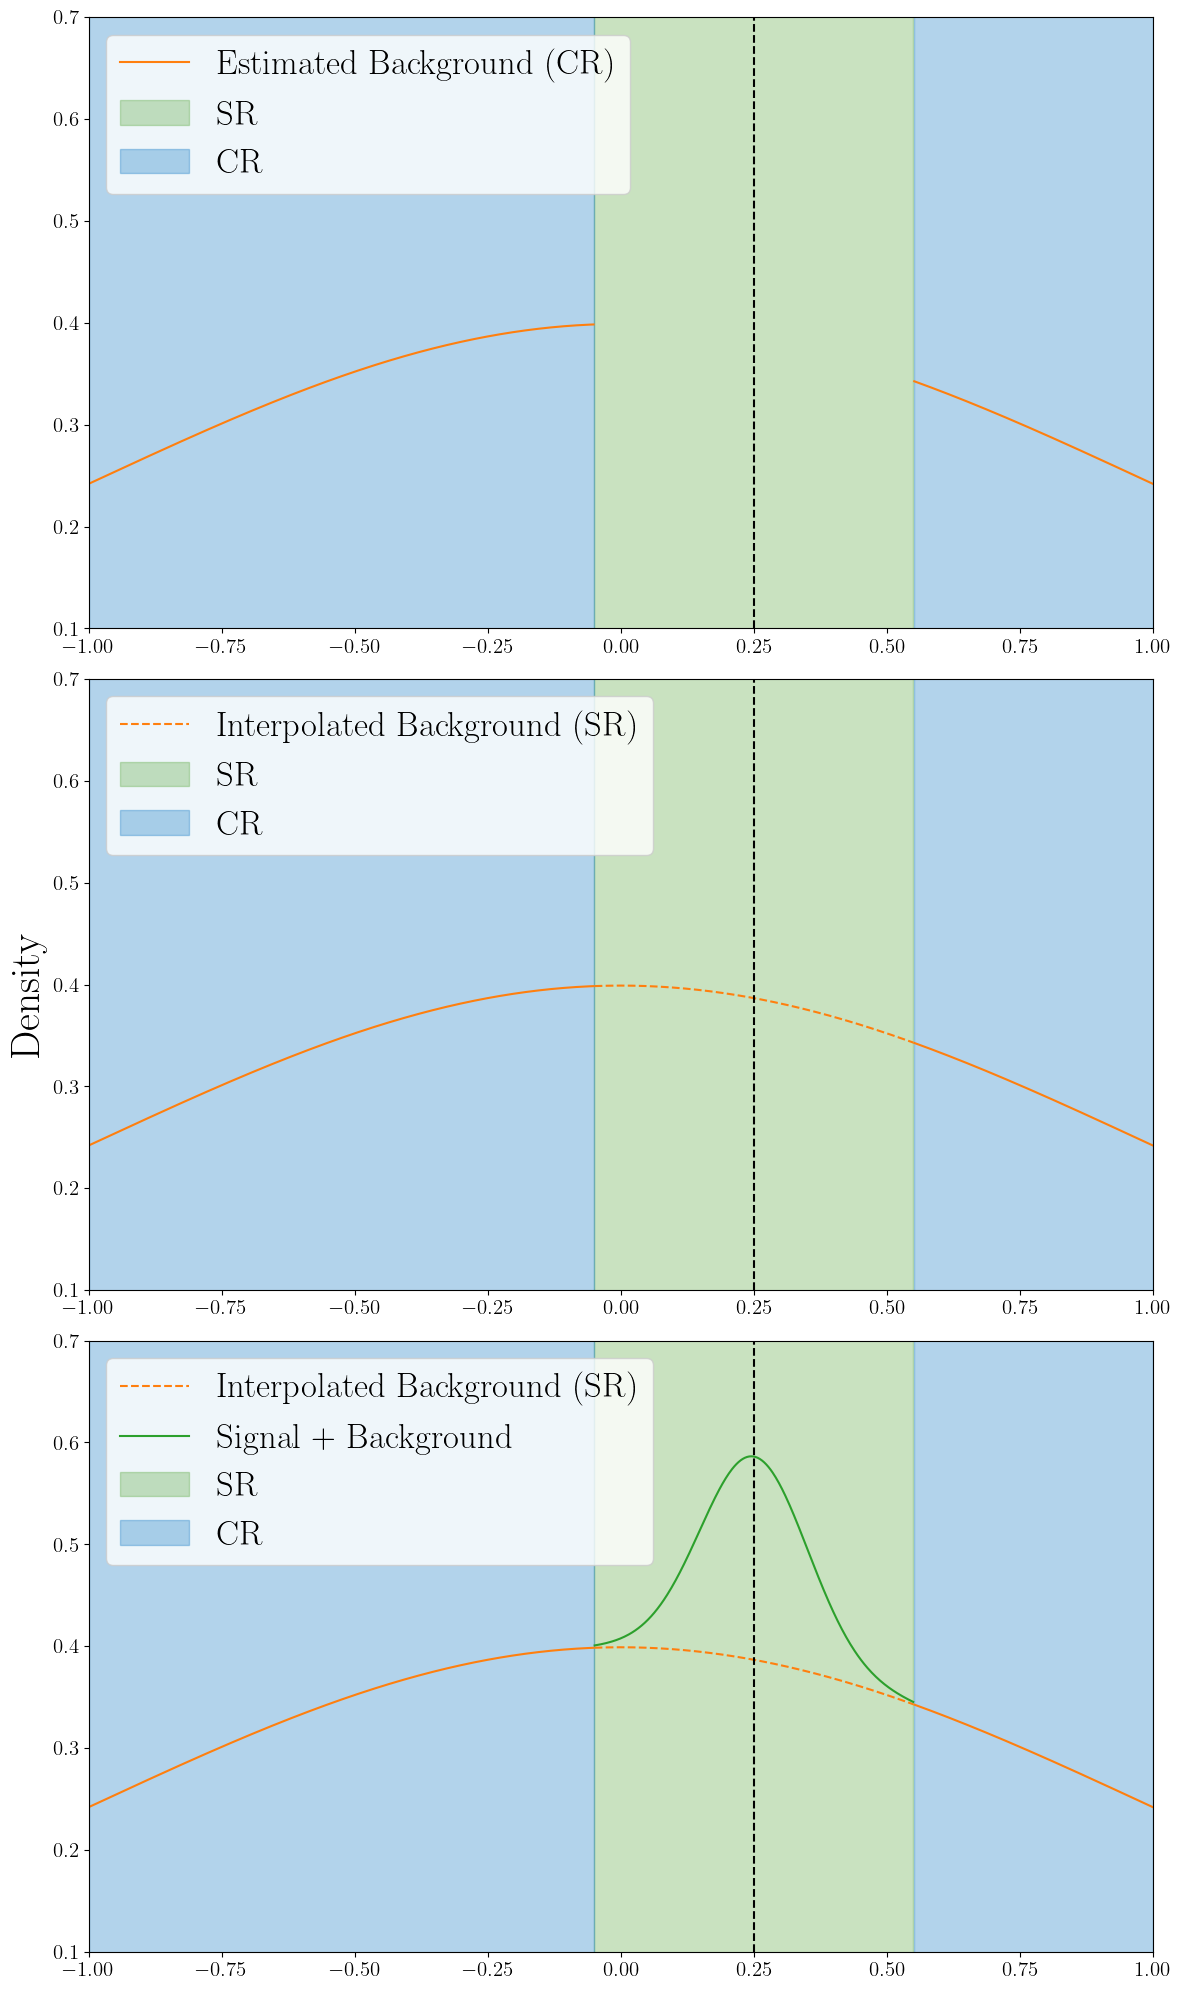

In [61]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(-1, 1, 1000)
pdf_1 = stats.norm.pdf(x_range, loc=0, scale=1)

signal_center = 0.25
signal_width = 0.1
pdf_2 = 0.05 * stats.norm.pdf(x_range, loc=signal_center, scale=signal_width)

sr_x1 = signal_center - 3 * signal_width
sr_x2 = signal_center + 3 * signal_width

in_SR = (x_range >= sr_x1) & (x_range <= sr_x2)
in_CR_left = (x_range < sr_x1)
in_CR_right = (x_range > sr_x2)
in_CR = in_CR_left | in_CR_right

fig, axs = plt.subplots(3, 1, figsize=(12, 20))
# fig.supxlabel("$x$", fontsize=30)
fig.supylabel("Density", fontsize=30)


axs[0].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1], label="Estimated Background (CR)")
axs[0].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
# axs[0].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Estimated Background (CR)")
# axs[0].plot(x_range[in_SR], pdf_1[in_SR] + pdf_2[in_SR], color=plt.cm.tab10.colors[2], label="Signal + Background")

axs[1].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1])
axs[1].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
axs[1].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Interpolated Background (SR)", color=plt.cm.tab10.colors[1])

axs[2].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Interpolated Background (SR)", color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_SR], pdf_1[in_SR] + pdf_2[in_SR], color=plt.cm.tab10.colors[2], label="Signal + Background")



CR_color = "#0070c0"
SR_color = "#4ea230"

for ax in axs:
    ax.axvline(signal_center, color="black", linestyle="--")
    ax.fill_betweenx(y=[0, 1], x1=sr_x1, x2=sr_x2, color=SR_color, alpha=0.3, label="SR")
    ax.fill_between(x_range, y1=0, y2=1, where=in_CR, color=CR_color, alpha=0.3, label="CR")
    ax.set_ylim(0.1, 0.7)
    ax.set_xlim(-1, 1)
    ax.legend(loc="upper left", fontsize=25)
    
    


plt.tight_layout()
plt.savefig("./figures/bg_estimation_toy_example.png", dpi=300)
plt.show()
plt.close()

3b-jet events:  275508
4b-jet events:  382108
HH4b-jet events:  28656


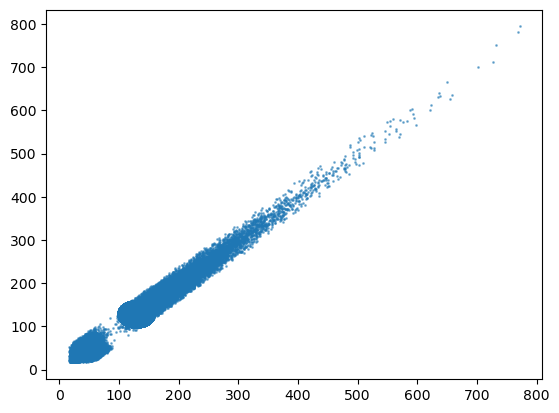

In [4]:
print(df_3b["SR"].mean())
print(df_3b["SB"].mean())
print(df_3b["CR"].mean())

0.5488878725844621
0.0
0.45111212741553786


In [3]:
import pathlib
import pandas as pd

events_directory = pathlib.Path("../events/MG3")


df_3b = pd.read_hdf(events_directory / "dataframes" / "threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf(events_directory / "dataframes" / "fourTag_10x_picoAOD.h5")
df_hh4b = pd.read_hdf(events_directory / "dataframes" / "HH4b_picoAOD.h5")

In [4]:
print(df_3b["weight"].sum())
print(df_3b["weight"].sum() / len(df_3b))

print(df_bg4b["weight"].sum())
print(df_bg4b["weight"].sum() / len(df_bg4b))

print(df_hh4b["weight"].sum())
print(df_hh4b["weight"].sum() / len(df_hh4b))

2299881.5
1.1424559498445932
2297896.5
1.043426051680523
33009.656
1.069797000583355


In [8]:
from dataset import generate_mother_dataset
from events_data import EventsData

n_3b = 1_400_000
ratio_4b = 0.5
signal_ratio = 0.02
signal_filename = "HH4b_picoAOD.h5"
seed = 42

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

for seed in range(0, 100):
    scd, df = generate_mother_dataset(
        n_3b=n_3b, 
        ratio_4b=ratio_4b,
        signal_ratio=signal_ratio,
        signal_filename=signal_filename,
        seed=seed)
    
    event = EventsData.from_dataframe(df, features=features)
    print(event.total_weight_signal)

31987.734
31987.387
31986.695
31992.738
31989.832
31984.98
31982.447
31988.812
31989.164
31992.648


KeyboardInterrupt: 